### Import Libs

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns   

df = pd.read_csv('../data/mmm_dataset.csv')
df.head()

,date,tv,youtube,facebook,search,sales
0,2021-01-03,24981.604754,512.653960,798.458312,6946.038172,13396.838847
1,2021-01-10,48028.572256,902.020129,858.729727,4951.309117,15890.848521
2,2021-01-17,39279.757672,1871.834473,1443.281375,5700.277729,14852.749319
3,2021-01-24,33946.339368,2229.737994,1579.036700,7979.767505,18527.788951
4,2021-01-31,16240.745618,2129.903149,1645.684374,2293.465623,17523.078768


### Adstock function

In [48]:
def adstock(x, alpha):

    result = np.zeros(len(x))

    for t in range(len(x)):

        if t == 0:

            result[t] = x[t]

        else:

            result[t] = x[t] + alpha * result[t-1]

    return result

### Apply adstock function

In [ ]:
theta_values =  {
    
    "tv": 0.7,
    "youtube": 0.5,
    "facebook": 0.4,
    "search": 0.2

}

df_theta=pd.DataFrame([theta_values])
df_theta.to_csv('../data/theta_values.csv')

for ch in ["tv", "youtube", "facebook", "search"]:
    df[f"{ch}_adstock"] = adstock(df[ch], theta_values[ch])


,tv,youtube,facebook,search
0,0.7,0.5,0.4,0.2


### Plots

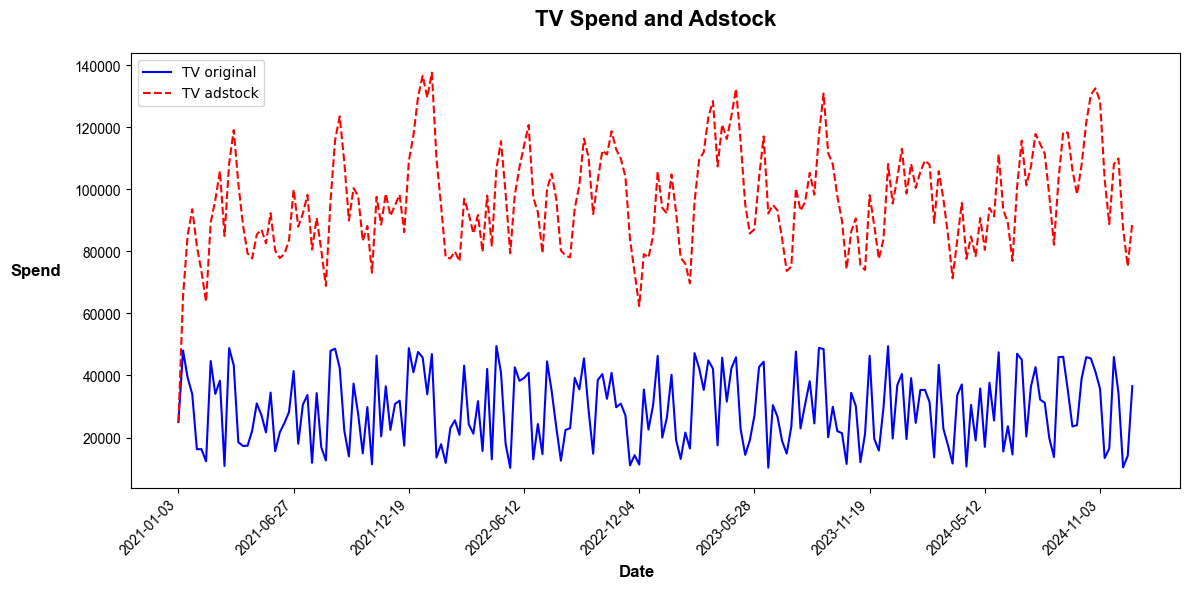

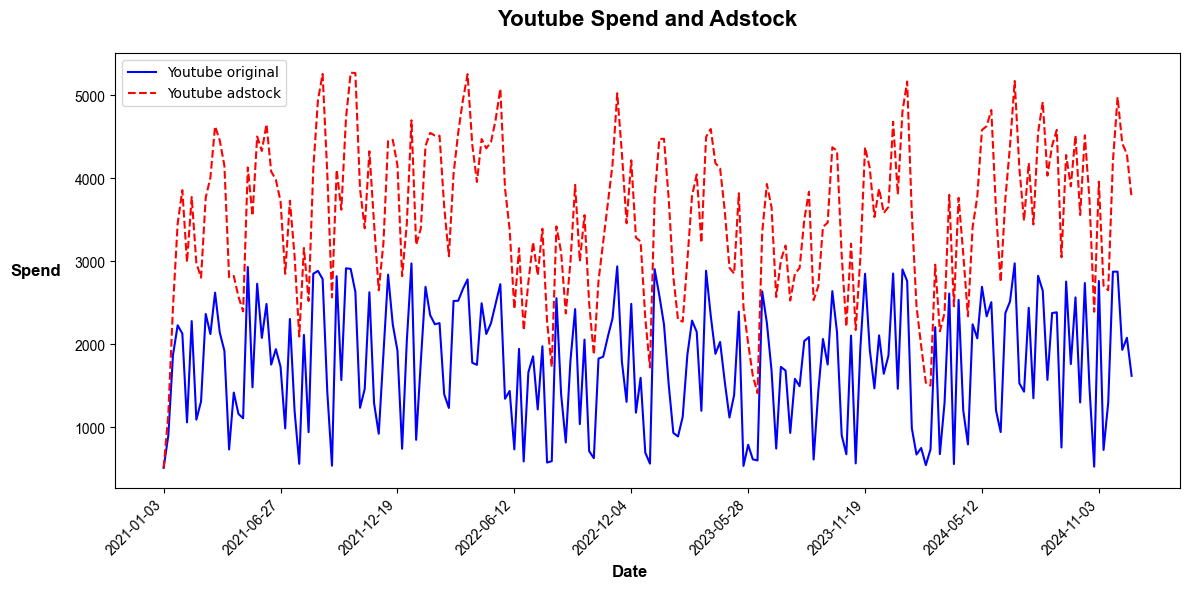

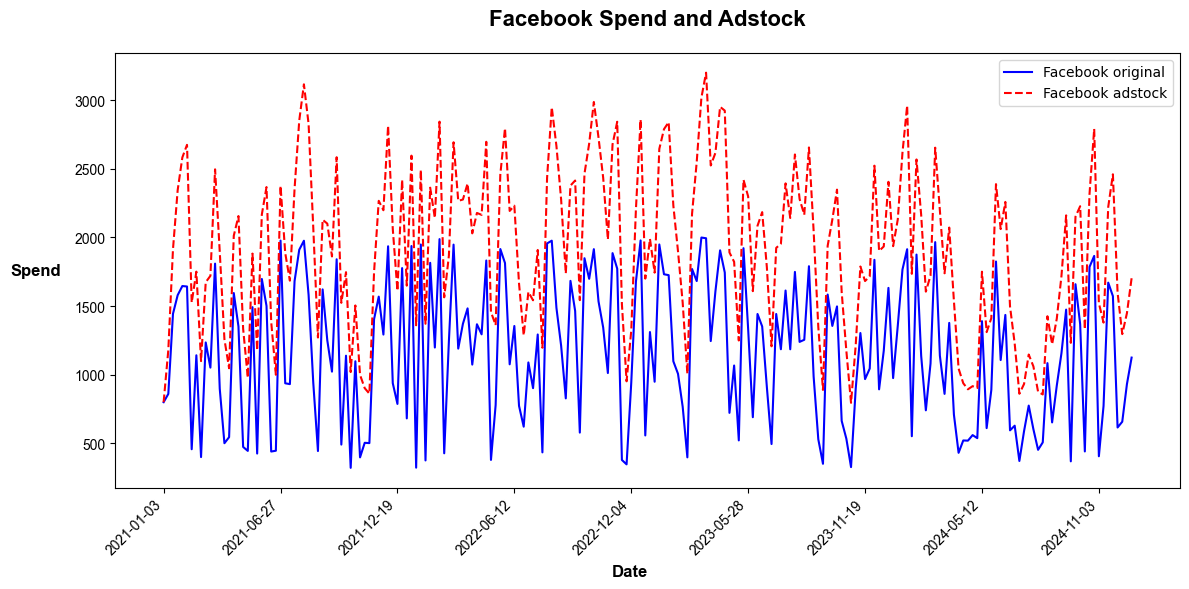

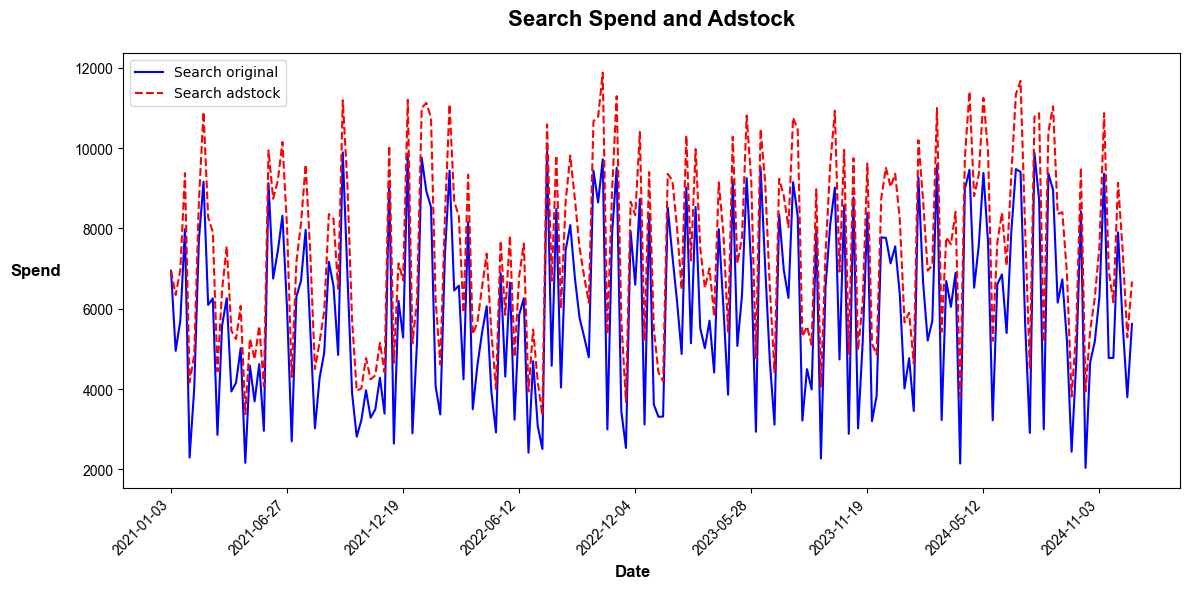

In [50]:
#TV Spend and Adstock plot

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['tv'], label = 'TV original', linestyle='-', color='blue')
plt.plot(df['date'], df['tv_adstock'], label = 'TV adstock', linestyle='--', color='red')
plt.title('TV Spend and Adstock', fontsize=16, color='black', fontweight='bold', pad=20, fontfamily='Arial')
plt.xlabel('Date', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.ylabel('Spend', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')

# Space the dates on the X-axis for better readability
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
plt.yticks(fontsize=10, color='black', fontfamily='Arial')
plt.legend()
plt.tight_layout()
plt.show()

# Youtube Spend and Adstock plot

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['youtube'], label = 'Youtube original', linestyle='-', color='blue')
plt.plot(df['date'], df['youtube_adstock'], label = 'Youtube adstock', linestyle='--', color='red')
plt.title('Youtube Spend and Adstock', fontsize=16, color='black', fontweight='bold', pad=20, fontfamily='Arial')
plt.xlabel('Date', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.ylabel('Spend', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')

# Space the dates on the X-axis for better readability
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
plt.yticks(fontsize=10, color='black', fontfamily='Arial')
plt.legend()
plt.tight_layout()
plt.show()

# Facebook Spend and Adstock plot

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['facebook'], label = 'Facebook original', linestyle='-', color='blue')
plt.plot(df['date'], df['facebook_adstock'], label = 'Facebook adstock', linestyle='--', color='red')
plt.title('Facebook Spend and Adstock', fontsize=16, color='black', fontweight='bold', pad=20, fontfamily='Arial')
plt.xlabel('Date', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.ylabel('Spend', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')

# Space the dates on the X-axis for better readability
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
plt.yticks(fontsize=10, color='black', fontfamily='Arial')
plt.legend()
plt.tight_layout()
plt.show()

# Search Spend and Adstock plot
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['search'], label = 'Search original', linestyle='-', color='blue')
plt.plot(df['date'], df['search_adstock'], label = 'Search adstock', linestyle='--', color='red')
plt.title('Search Spend and Adstock', fontsize=16, color='black', fontweight='bold', pad=20, fontfamily='Arial')
plt.xlabel('Date', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')
plt.ylabel('Spend', fontsize=12, color='black', fontweight='bold', labelpad=10, rotation=0, ha='right', va='center', fontfamily='Arial')

# Space the dates on the X-axis for better readability
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
plt.yticks(fontsize=10, color='black', fontfamily='Arial')
plt.legend()
plt.tight_layout()
plt.show()

### Saturation

In [51]:
def saturation(x, lam):

    return 1 - np.exp(-lam * x)

In [72]:
### Calculate lambda values for each channel based on the adstocked values 

channels = ["tv_adstock", "youtube_adstock", "facebook_adstock", "search_adstock"]
lam_values = {}

for ch in channels:
    mean_val = df[ch].mean()
    lam = -np.log(0.5) / mean_val
    lam_values[ch] = lam

lam_values
lam_df = pd.DataFrame([lam_values])
lam_df.to_csv('../data/lam_values.csv', index = False)


### Calculate saturation for each channel

In [53]:
df['tv_sat'] = saturation(df['tv_adstock'], lam_values['tv_adstock'])
df['youtube_sat'] = saturation(df['youtube_adstock'], lam_values['youtube_adstock'])
df['facebook_sat'] = saturation(df['facebook_adstock'], lam_values['facebook_adstock'])
df['search_sat'] = saturation(df['search_adstock'], lam_values['search_adstock'])

#save df processed

df.to_csv('../data/processed_dataset.csv')

### Plots

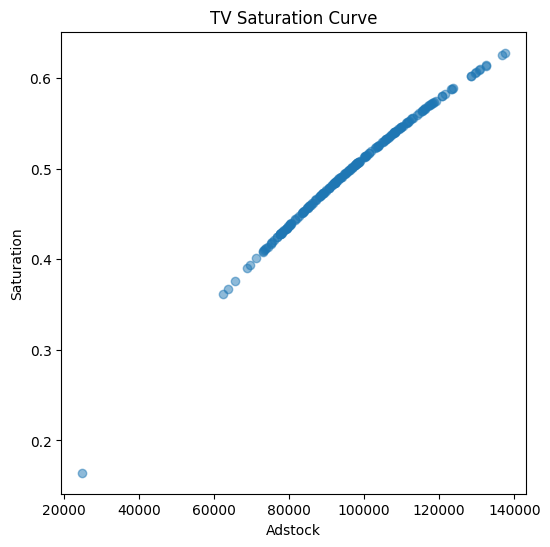

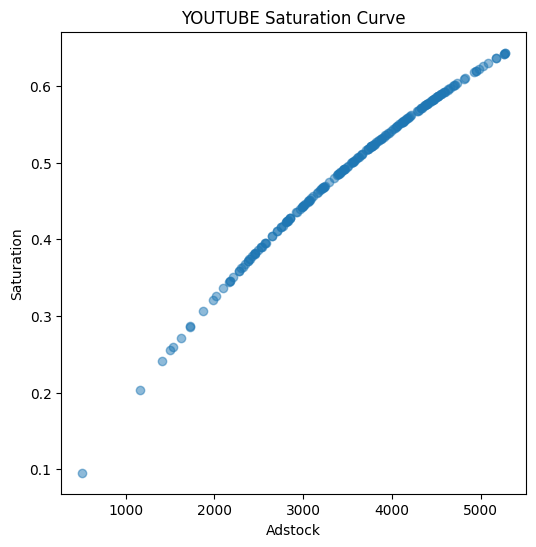

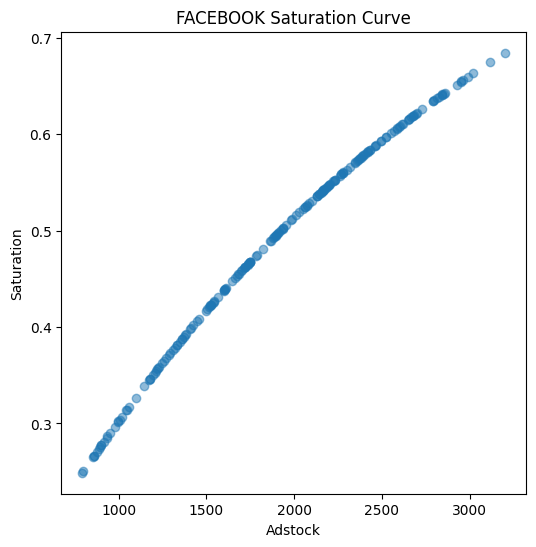

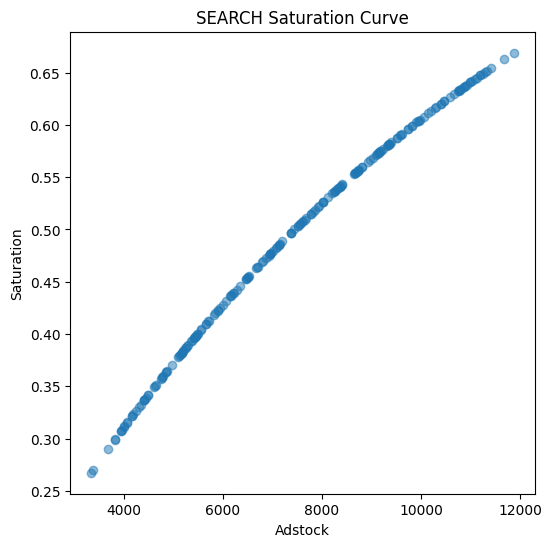

In [54]:
# TV saturation curve plot
channels = ["tv", "youtube", "facebook", "search"]

for ch in channels:
    plt.figure(figsize=(6,6))
    plt.scatter(df[f"{ch}_adstock"], df[f"{ch}_sat"], alpha=0.5)
    plt.title(f"{ch.upper()} Saturation Curve")
    plt.xlabel("Adstock")
    plt.ylabel("Saturation")
    plt.show()

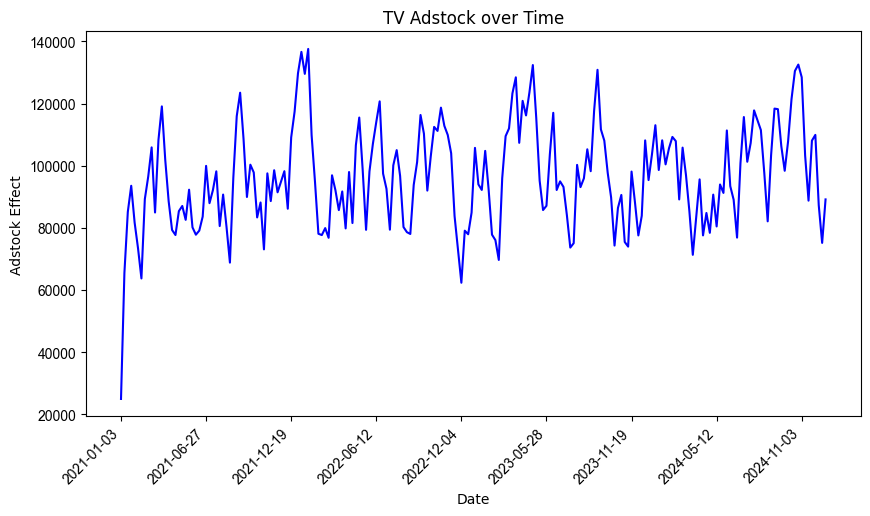

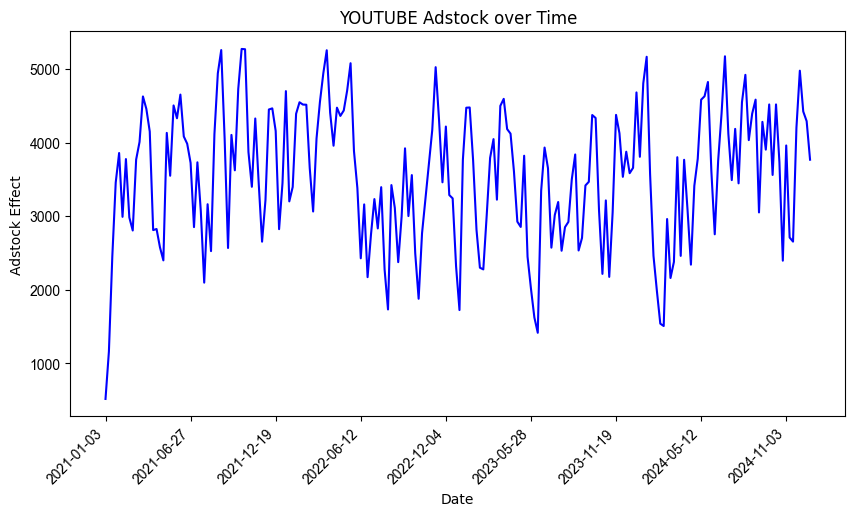

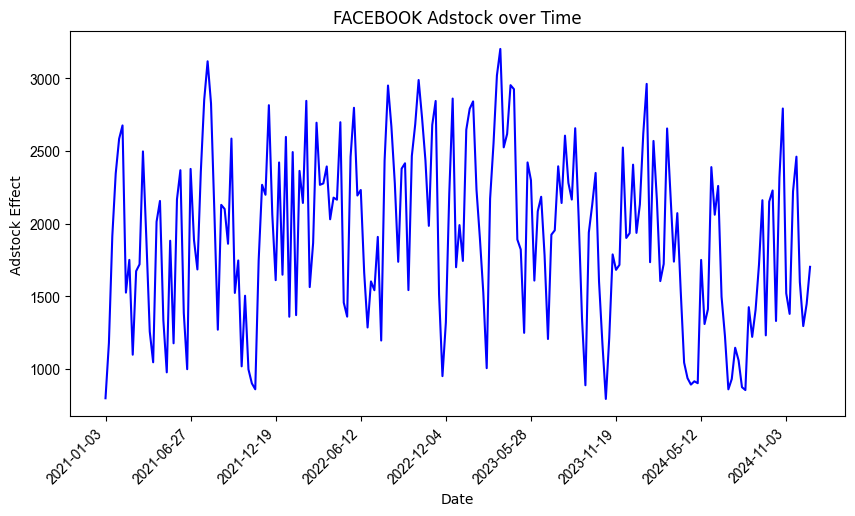

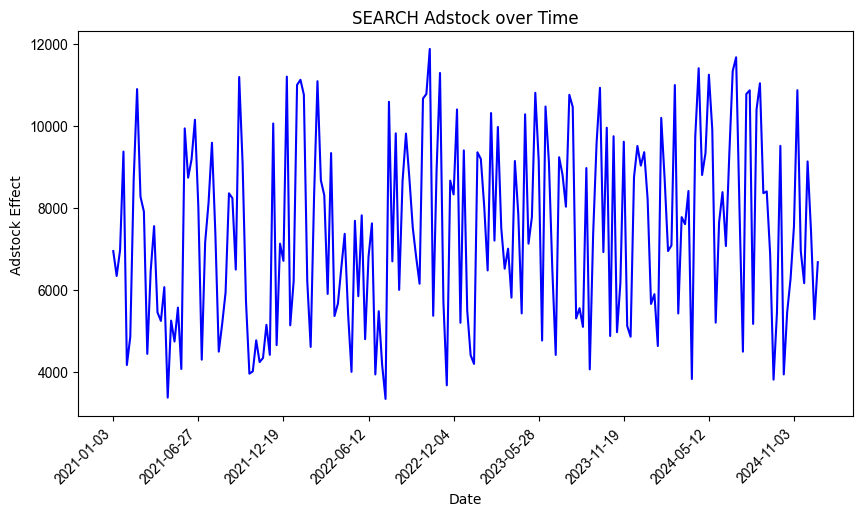

In [55]:
import matplotlib.pyplot as plt



for ch in channels:
    plt.figure(figsize=(10,5))
    plt.plot(df["date"], df[f"{ch}_adstock"], color='blue')
    plt.title(f"{ch.upper()} Adstock over Time")
    plt.xlabel("Date")
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

    plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
    plt.yticks(fontsize=10, color='black', fontfamily='Arial')
    plt.ylabel("Adstock Effect")
    plt.show()

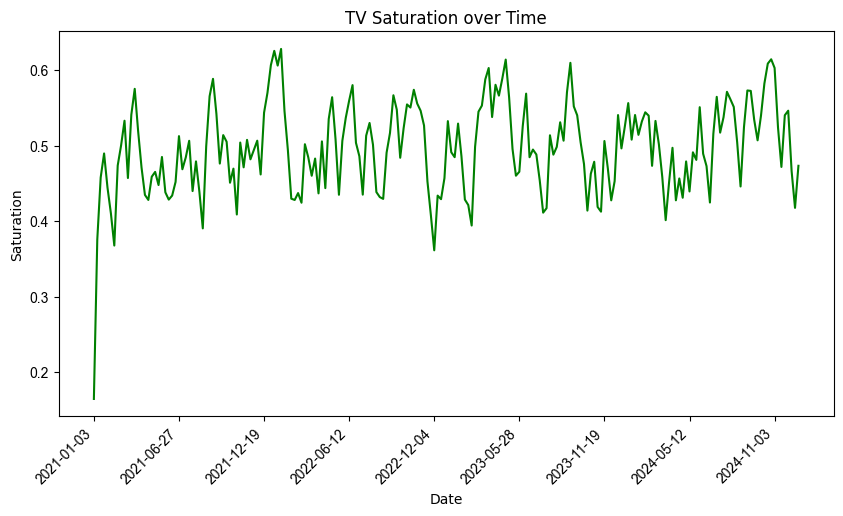

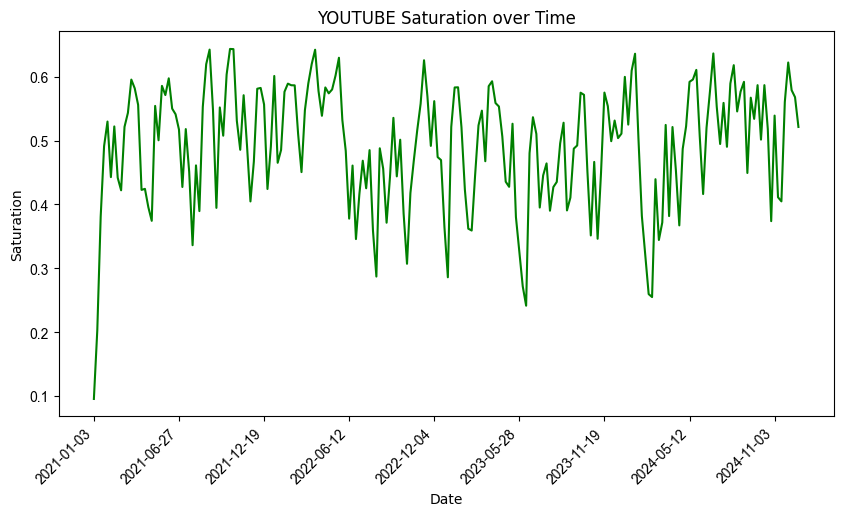

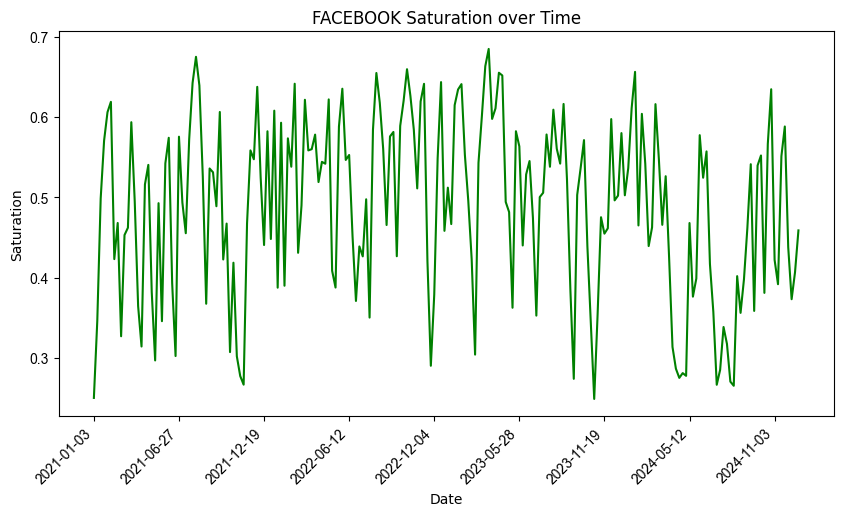

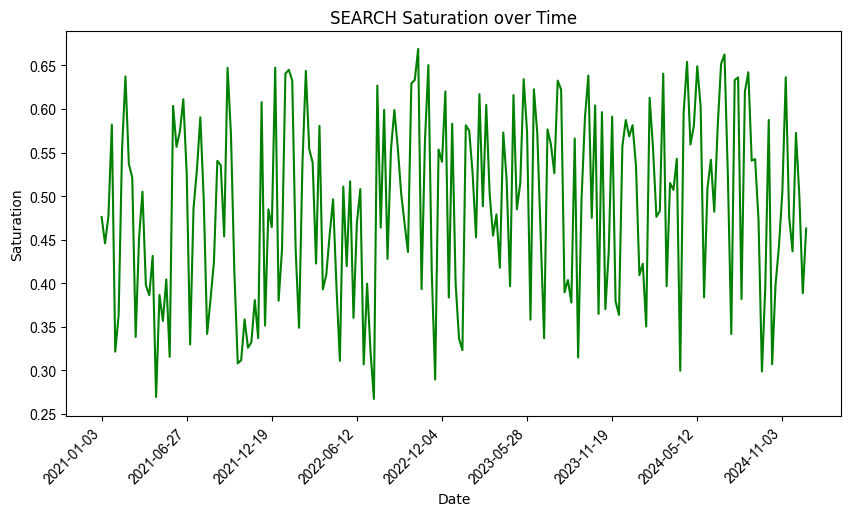

In [56]:
for ch in channels:
    plt.figure(figsize=(10,5))
    plt.plot(df["date"], df[f"{ch}_sat"], color='green')
    plt.title(f"{ch.upper()} Saturation over Time")
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

    plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontfamily='Arial')
    plt.yticks(fontsize=10, color='black', fontfamily='Arial')
    plt.xlabel("Date")
    plt.ylabel("Saturation")
    plt.show()

Adstock curves show the carryover effect of media spend, while saturation curves reflect diminishing returns, normalizing the media impact between 0 and 1.